<p align="center">
  <a href="https://imc.uc.cl" target="_blank">
    <img src="attachment:dbc13321-47df-4da0-85d8-6f7591c31d88.png" alt="IMC" width="220">
  </a>
</p>

# IMT 2200 - Introducción a Ciencia de Datos
**Pontificia Universidad Católica de Chile**<br>
**Instituto de Ingeniería Matemática y Computacional**<br>
**Semestre 2025-S2**<br>
**Profesor:** Rodrigo A. Carrasco <br>
---

# <h1><center>Actividad 10 - Aprendizaje supervisado: clasificación</center></h1>

Esta actividad busca aplicar distintos tipos de modelos para la clasificación de datos, además de analizar y comprender sus resultados.

## Instrucciones

Este Notebook contiene las instrucciones a realizar para la actividad. 

<b>Al finalizarla, deben subir el Notebook y los archivos generados en un único archivo .zip, al módulo de la Actividad 10 en Canvas.</b>

## Contexto

En astronomía, casi todo lo que conocemos sobre el universo observable proviene del estudio de la luz que llega a la Tierra.
A la medición de la cantidad de luz (o flujo) que emiten distintos objetos astronómicos se le llama **fotometría**.
Más específicamente, los astrónomos clasifican estos objetos a partir de la cantidad de flujo para distintas áreas del espectro de la luz (longitudes de onda). Esto se realiza utilizando filtros ópticos que permiten el paso de la luz solo para un rango limitado de longitudes de onda.

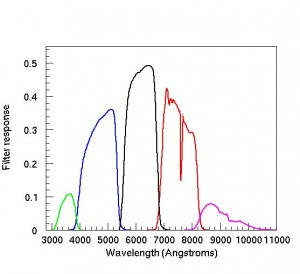

(Filtros *u, g, r, i, z* usados por SLOAN. Fuente: https://www.sdss4.org/instruments/camera/#Filters)

Los datos fotométricos que se obtienen corresponden a la cantidad de fotones detectados para cada longitud de onda, mediante los cuales los astrónomos pueden generar el espectro de un objeto.

Para esta actividad, utilizaremos datos de 100.000 mediciones hechas por el Sloan Digital Sky Survey (SDSS) y puestos a disposición del público el año 2022. El dataset original puede encontrarse aquí: https://www.kaggle.com/datasets/fedesoriano/stellar-classification-dataset-sdss17

#### Objetivo específico

Nuestro objetivo será entrenar y comparar modelos de aprendizaje supervisado capaces de diferenciar entre **estrellas, galaxias y cuásares** a partir de datos fotométricos.

## Rúbrica

- Si han logrado todo: 7.0
- Si han logrado hasta la pregunta 2: 5
- Si han logrado hasta la pregunta 3: 7
- La pregunta 4 es un bono adicional.

In [2]:
# acá van algunas librerías útiles, pero pueden agregar las adicionales que deseeen
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from random import sample
from sklearn.model_selection import train_test_split

## 1. Lectura e inspección inicial

1. Lea el archivo `star_classification.csv` en un DataFrame, imprima todas sus columnas y sus estadísticos principales.

2. Identifique la columna que representa su vector $y$ (target, la etiqueta a clasificar). Transforme los valores a etiquetas numéricas para que puedan ser leídas por un modelo predictor.

3. Realice un gráfico que muestre la cantidad total de estrellas, galaxias y cuásares en su dataset. Responda:
* ¿Cómo se distribuyen estos datos? ¿Cuáles son sus respectivos porcentajes en relación al total de los datos?
* ¿Cómo cree que esta distribución podría afectar a un modelo de clasificación? Responda utilizando los términos de precisión y recall.

4. Grafique la matriz de correlación entre las columnas de su dataset. ¿Cuáles son las dos columnas con el mayor valor absoluto de correlación con la clase del objeto?

5. Utilice estas dos columnas como eje X e Y para graficar un scatterplot de sus datos. Use colores diferentes para representar las 3 clases, estrellas, galaxias y cuásares. (**Opción:** en `matplotlib.plotly`, puede utilizar la opción `plt.xscale("log")` o  `plt.yscale("log")` para modificar la escala de visualización de un eje.)

In [3]:
# respuesta 1.1
df_inicial = pd.read_csv('data 2025/star_classification.csv')
df_inicial.sample(5)
print('\nColumnas de df_inical:')
display(df_inicial.columns)
print('\nCuyos datos descriptivos son:')
display(df_inicial.describe())
print('\nMostramos las primeras 5 entradas del dataframe inical:')
display(df_inicial.head())


Columnas de df_inical:


Index(['obj_ID', 'alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'run_ID',
       'rerun_ID', 'cam_col', 'field_ID', 'spec_obj_ID', 'class', 'redshift',
       'plate', 'MJD', 'fiber_ID'],
      dtype='object')


Cuyos datos descriptivos son:


,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,redshift,plate,MJD,fiber_ID
count,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.0,100000.000000,100000.000000,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000
mean,1.237665e+18,177.629117,24.135305,21.980468,20.531387,19.645762,19.084854,18.668810,4481.366060,301.0,3.511610,186.130520,5.783882e+18,0.576661,5137.009660,55588.647500,449.312740
std,8.438560e+12,96.502241,19.644665,31.769291,31.750292,1.854760,1.757895,31.728152,1964.764593,0.0,1.586912,149.011073,3.324016e+18,0.730707,2952.303351,1808.484233,272.498404
min,1.237646e+18,0.005528,-18.785328,-9999.000000,-9999.000000,9.822070,9.469903,-9999.000000,109.000000,301.0,1.000000,11.000000,2.995191e+17,-0.009971,266.000000,51608.000000,1.000000
25%,1.237659e+18,127.518222,5.146771,20.352353,18.965230,18.135828,17.732285,17.460677,3187.000000,301.0,2.000000,82.000000,2.844138e+18,0.054517,2526.000000,54234.000000,221.000000
50%,1.237663e+18,180.900700,23.645922,22.179135,21.099835,20.125290,19.405145,19.004595,4188.000000,301.0,4.000000,146.000000,5.614883e+18,0.424173,4987.000000,55868.500000,433.000000
75%,1.237668e+18,233.895005,39.901550,23.687440,22.123767,21.044785,20.396495,19.921120,5326.000000,301.0,5.000000,241.000000,8.332144e+18,0.704154,7400.250000,56777.000000,645.000000
max,1.237681e+18,359.999810,83.000519,32.781390,31.602240,29.571860,32.141470,29.383740,8162.000000,301.0,6.000000,989.000000,1.412694e+19,7.011245,12547.000000,58932.000000,1000.000000



Mostramos las primeras 5 entradas del dataframe inical:


,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,GALAXY,0.634794,5812,56354,171
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,GALAXY,0.779136,10445,58158,427
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,GALAXY,0.644195,4576,55592,299
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030107e+19,GALAXY,0.932346,9149,58039,775
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891865e+18,GALAXY,0.116123,6121,56187,842


In [4]:
#respuesta 1.2
columna_target = 'class'
columna_atributos = ['u', 'g', 'r', 'i', 'z', 'redshift']

Y = df_inicial[columna_target]
X = df_inicial[columna_atributos]

display(X.sample(3).sort_index())
display(Y.sample(3).sort_index())


,u,g,r,i,z,redshift
61612,18.33420,17.17129,16.74267,16.49889,16.33134,0.045276
63410,24.56996,23.24376,21.60266,20.54999,19.86738,0.661770
75086,24.63010,20.95465,19.71521,18.93266,18.43430,0.228969


37592    GALAXY
66054      STAR
89501    GALAXY
Name: class, dtype: object

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, 
    test_size=0.3, 
    random_state=5
    )

In [6]:
len(X_train)

70000

/var/folders/hf/z4nqpl692qq20c0yrl9q93r40000gn/T/ipykernel_10433/958654361.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_inicial, x='class', palette='viridis')


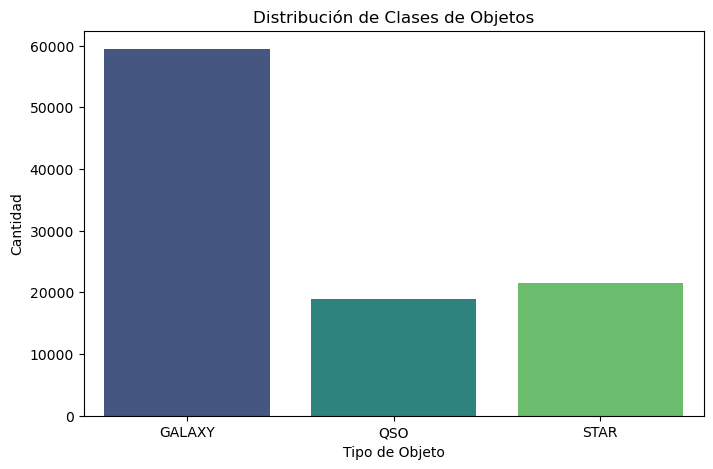

In [7]:

# Definir un tamaño de figura
plt.figure(figsize=(8, 5))

# La función countplot hace el conteo y el gráfico en un solo paso
ax = sns.countplot(data=df_inicial, x='class', palette='viridis')

# Añadimos etiquetas para que sea legible
ax.set_title('Distribución de Clases de Objetos')
ax.set_xlabel('Tipo de Objeto')
ax.set_ylabel('Cantidad')

# Mostrar el gráfico
plt.show()

### Respuesta 1.3
Podemos apreciar que el dataser esta evidentemente desbalanceado, no tenemos la misma cantidad de ejemplos para cada clase. Existen aproximadamente 3 veces mas galaxias que QSO. Recordemos que los nombres de cada grafico provienen de la columna `class`.

Dado que el dataset está desbalanceado (predomina `GALAXY`), el modelo se volverá muy bueno prediciendo esta clase, probablemente logrando una alta precisión y alto recall para ella. Pero, esto a su vez, afectará negativamente a las clases QSO y STAR: al modelo le costará aprender sus patrones y tendrá un bajo recall para ellas, lo que significa que muchos cuásares y estrellas reales serán "ignorados" o clasificados incorrectamente como **galaxias**.

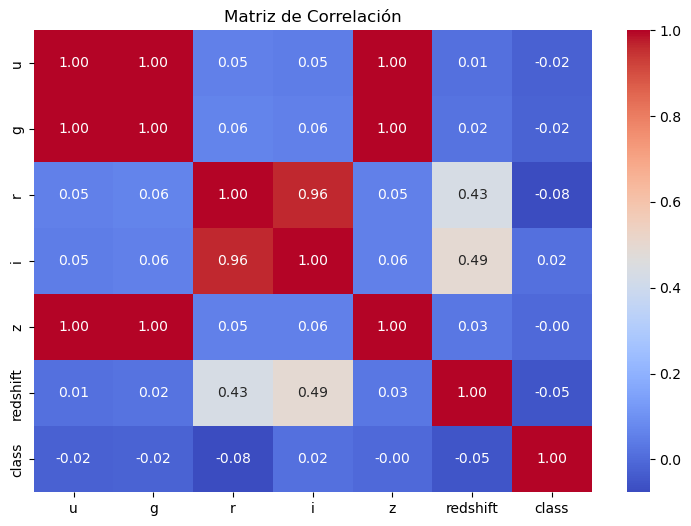

In [8]:
# respuesta 1.4

columnas_plot = ['u', 'g', 'r', 'i', 'z', 'redshift', 'class']
df_plot = df_inicial[columnas_plot].copy()

#convierto la columna class a categoria de numeros
df_plot['class'] = df_plot['class'].astype('category').cat.codes

#matriz de correlación
corr_matrix = df_plot.corr()

plt.figure(figsize=(9, 6))
sns.heatmap(corr_matrix, 
            annot=True,     # Muestra los números en las celdas
            fmt='.2f',      # Redondea a 2 decimales
            cmap='coolwarm') # Paleta de color (rojo-azul)
plt.title('Matriz de Correlación')

plt.show()

Basado en la matriz, las dos columnas que tienen el mayor valor absoluto de correlación con la clase del objeto son r y redshift. La columna r tiene el valor más alto con 0.08, seguida por redshift con 0.05.

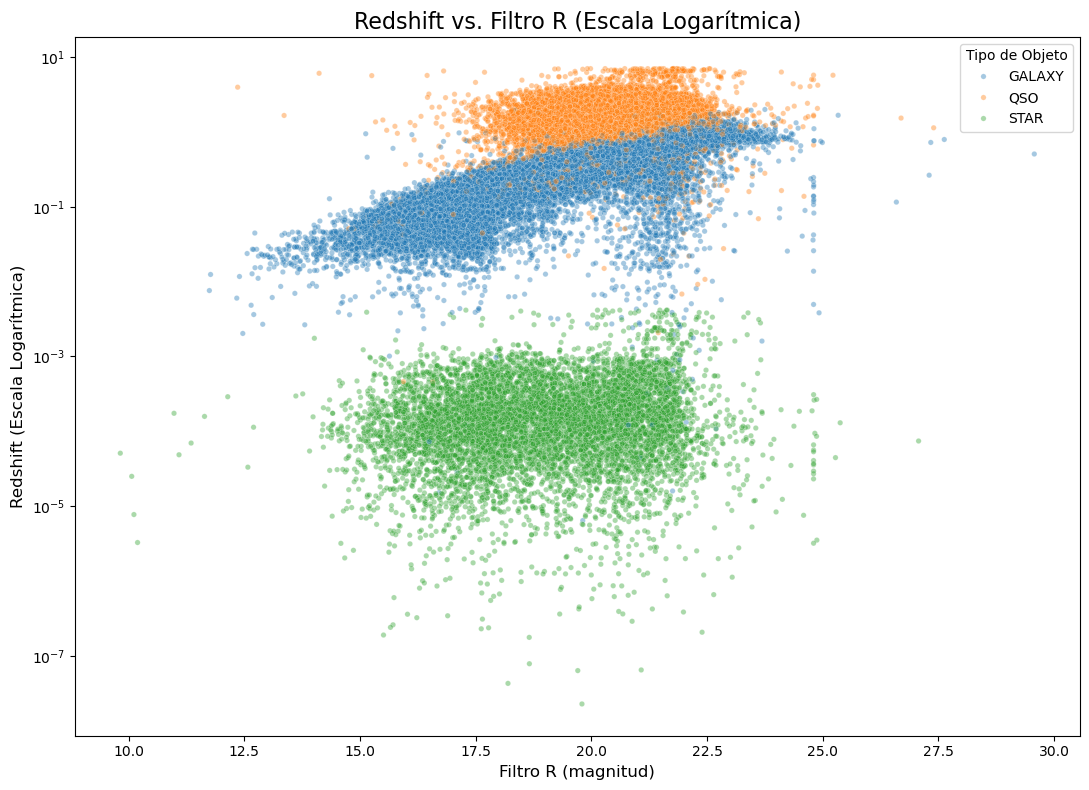

In [9]:
#respuesta 1.5

# Definir el tamaño de la figura
plt.figure(figsize=(11, 8))

# Crear el scatterplot con Seaborn
# hue='class' es el argumento clave que colorea automáticamente
ax = sns.scatterplot(data=df_inicial, 
                     x='r', 
                     y='redshift', 
                     hue='class',   
                     alpha=0.4,
                     s=15)

#gracias a esto distinguimos entre galaxy y star
ax.set_yscale("log")

ax.set_title('Redshift vs. Filtro R (Escala Logarítmica)', fontsize=16)
ax.set_xlabel('Filtro R (magnitud)', fontsize=12)
ax.set_ylabel('Redshift (Escala Logarítmica)', fontsize=12)
ax.legend(title='Tipo de Objeto')
plt.tight_layout()
plt.show()

## 2. Preparando los datos para entrenar

Para entrenar nuestros modelos, vamos a probar y comparar dos acercamientos:

1. Cree la matriz $X_1$ que contenga todas las columnas de atributos disponibles en su dataframe. Por otra parte, cree $X_2$, pero esta vez solamente considere los datos fotométricos obtenidos en los 5 filtros que utiliza SLOAN, además del [redshift](https://es.wikipedia.org/wiki/Corrimiento_al_rojo) (corrimiento al rojo).

2. Cree el vector $y$ con las etiquetas a predecir.

3. Para $X_1$ y $X_2$ por separado, separe sus datos en conjuntos de entrenamiento y prueba (como matrices de atributos debería tener `X1_train, X1_test, X2_train, X2_test`).
No olvide normalizar todas sus matrices de atributos.

In [10]:
# algunas librerías útiles, puede agregar otras si las necesita
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# respuestas


## 3. Predictores

#### 3.1 KNN con todos los atributos ($X_1$)
Ahora vamos a crear nuestro primer modelo predictor. Entrene un modelo KNN con sus conjunto de entrenamiento `X1_train` y evalúelo solamente para el conjunto de prueba `X1_test`, retornando lo siguiente:
* Accuracy
* Precisión
* Recall
* F1
* Matriz de confusión (haga un gráfico que muestre estos valores)

#### 3.2 Árbol de decisión con todos los atributos ($X_1$)

Repita el proceso, esta vez con un modelo de tipo árbol de decisión. 

Responda:
* ¿Cómo se comportan los modelos? ¿Sucede o no sucede lo que esperaba (su respuesta a la sección 1.3)?
* ¿Cuál modelo tiene mejor desempeño?

In [11]:
# respuestas


Respuestas: 

#### 3.3 KNN con atributos filtrados ($X_2$)

Ahora, repetiremos el mismo proceso, pero utilizando nuestra matriz de atributos filtrados $X_2$. Entrene un modelo KNN con la misma cantidad de `n_neighbors`que definió para la sección 3.1. Nuevamente, imprima las mismas métricas y genere un gráfico de la matriz de confusión.

#### 3.4 Árbol de decisión con atributos filtrados ($X_2$)

Repita el proceso para el modelo de tipo árbol de decisión. También utilice los mismos hiperparámetros que utilizó en la sección 3.2.

Responda: 
* ¿Cómo se comportan ahora sus modelos? ¿Cómo se comparan con sus versiones anteriores?
* ¿Cuál de los 4 modelos elegiría?

In [12]:
# respuestas

Respuestas:

## 4. Preguntas (BONUS de +1 punto)

Investigue en internet brevemente sobre el entrenamiento de modelos clasificadores con bases de datos desbalanceadas (*imbalabced data*) y responda:

* ¿Qué otras técnicas existen para abarcar estos problemas? Mencione y explique de manera concisa al menos 2.
* ¿Qué modelos suelen tener mejor desempeño en estos contextos? ¿Por qué?

Respuestas: